# Conflict Escalation Dashboard (Colab, Sectioned)

This notebook is structured to run **top to bottom** in Google Colab.

It will:

1. install packages
2. import libraries
3. pull market data
4. optionally pull GDELT / ACLED data
5. build the conflict escalation model
6. create charts
7. export CSV files
8. generate a formatted PDF report

## Notes
- If GDELT rate-limits you, the notebook will continue and fall back to market-only signals.
- If ACLED credentials are not provided, the notebook will continue without ACLED.
- Run **Runtime → Run all** in Colab for the smoothest experience.

In [1]:

# SECTION 1 — Install packages
!pip -q install yfinance requests pandas numpy matplotlib plotly reportlab kaleido scipy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 19.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 69.0/69.0 kB 2.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.3/49.3 kB 1.7 MB/s eta 0:00:00


In [2]:

# SECTION 2 — Imports
import os
import time
import random
import warnings
from datetime import datetime

import requests
import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt
import plotly.graph_objects as go

from scipy.special import softmax

warnings.filterwarnings("ignore")

# Optional: nicer dataframe display in Colab/Jupyter
from IPython.display import display, Markdown

## Section 3 — Configuration

Set the model knobs here.

`ENABLE_GDELT` is left on by default, but the query count is intentionally reduced to lower rate-limit risk.

In [3]:

# SECTION 3 — Configuration

LOOKBACK_DAYS = 90
NEWS_LOOKBACK_DAYS = 30

ENABLE_GDELT = True
ENABLE_ACLED = False   # set True only if you provide credentials below

# Reduce GDELT query count to improve reliability in Colab shared runtimes
GDELT_QUERY_SET = {
    "iran_conflict_volume": '"Iran" AND ("Israel" OR "United States") AND (missile OR strike OR drone)',
    "ceasefire_volume": '("Iran" AND "Israel") AND (ceasefire OR negotiation OR mediation OR talks)',
    "iran_conflict_tone": '"Iran" AND ("Israel" OR "United States") AND (missile OR strike OR drone)',
    "hormuz_tone": '"Strait of Hormuz" AND (shipping OR tanker OR blockade OR disruption)'
}

# Optional ACLED credentials
# In Colab, you can set:
# import os
# os.environ["ACLED_EMAIL"] = "your_email"
# os.environ["ACLED_PASSWORD"] = "your_password"
ACLED_EMAIL = os.getenv("ACLED_EMAIL", "")
ACLED_PASSWORD = os.getenv("ACLED_PASSWORD", "")

TODAY = pd.Timestamp.utcnow().normalize()
START_DATE = TODAY - pd.Timedelta(days=LOOKBACK_DAYS)

# Market tickers
TICKERS = [
    "BZ=F",   # Brent crude
    "CL=F",   # WTI crude
    "NG=F",   # Nat gas
    "^VIX",   # VIX
    "UUP",    # USD proxy
    "XLE",    # Energy equities
    "XLI",    # Industrials
    "ITA",    # Defense / aerospace proxy
    "GLD",    # Gold
    "TLT",    # Long duration Treasuries
    "HYG",    # High yield credit
    "SPY"     # Broad equity benchmark
]

OUTPUT_CSV_FULL = "conflict_escalation_dashboard_output.csv"
OUTPUT_CSV_LATEST = "conflict_dashboard_latest.csv"
OUTPUT_PDF = "conflict_dashboard_report.pdf"
OUTPUT_IMG_ESC = "conflict_escalation_chart.png"
OUTPUT_IMG_DUR = "conflict_duration_chart.png"
OUTPUT_IMG_CONTRIB = "signal_contributions_chart.png"

## Section 4 — Helper functions

In [4]:

# SECTION 4 — Helper functions

def robust_get(url, params=None, headers=None, timeout=30, max_retries=6):
    """
    HTTP GET with exponential backoff. Raises the last real exception if all retries fail.
    """
    last_err = RuntimeError("Request failed without a captured exception.")

    for attempt in range(max_retries):
        try:
            r = requests.get(url, params=params, headers=headers, timeout=timeout)

            if r.status_code == 429:
                wait = min((2 ** attempt) + random.uniform(0.5, 1.5), 20)
                print(f"Rate-limited (429). Sleeping {wait:.1f}s...")
                time.sleep(wait)
                continue

            r.raise_for_status()
            return r

        except requests.exceptions.RequestException as e:
            last_err = e
            wait = min((2 ** attempt) + random.uniform(0.5, 1.5), 20)
            time.sleep(wait)

    raise last_err


def safe_json(response):
    """
    Some APIs occasionally return empty or invalid JSON bodies.
    """
    try:
        return response.json()
    except Exception as e:
        raise ValueError(f"Failed to decode JSON: {e}")


def safe_pct_change(series, periods=1):
    s = series.copy()
    return s.pct_change(periods=periods).replace([np.inf, -np.inf], np.nan)


def rolling_zscore(series, window=20):
    mean = series.rolling(window).mean()
    std = series.rolling(window).std()
    z = (series - mean) / std
    return z.replace([np.inf, -np.inf], np.nan)


def clip_series(series, low=-3, high=3):
    return series.clip(lower=low, upper=high)


def normalize_to_minus1_plus1(z, clip=3):
    """
    Converts z-like values to [-1, +1].
    """
    z = np.clip(z, -clip, clip)
    return z / clip


def fmt_num(x, nd=3):
    try:
        return f"{float(x):.{nd}f}"
    except Exception:
        return str(x)


def fmt_pct(x):
    try:
        return f"{float(x):.1%}"
    except Exception:
        return str(x)

## Section 5 — Data pull functions

In [5]:

# SECTION 5 — Data pull functions

GDELT_BASE = "https://api.gdeltproject.org/api/v2/doc/doc"


def extract_close(df, ticker):
    if len(df.columns) == 0:
        return pd.Series(dtype=float)
    try:
        if ticker not in df.columns.get_level_values(0):
            return pd.Series(dtype=float)
        x = df[ticker]["Close"].copy()
        x.name = ticker
        return x
    except Exception:
        return pd.Series(dtype=float)


def pull_market_data():
    market = yf.download(
        tickers=TICKERS,
        start=START_DATE.strftime("%Y-%m-%d"),
        end=(TODAY + pd.Timedelta(days=1)).strftime("%Y-%m-%d"),
        auto_adjust=True,
        progress=False,
        group_by="ticker",
    )

    market_close = pd.DataFrame({t: extract_close(market, t) for t in TICKERS}).sort_index()
    return market_close


def gdelt_timeline(query, mode="TimelineVol", timespan="30d"):
    """
    Pull GDELT timeline data safely.
    Returns a pandas Series indexed by date.
    """
    params = {
        "query": query,
        "mode": mode,
        "format": "json",
        "timespan": timespan,
    }

    r = robust_get(GDELT_BASE, params=params, timeout=45)
    data = safe_json(r)

    if not isinstance(data, dict):
        return pd.Series(dtype=float)

    timeline_candidates = []
    for key in ["timeline", "timelineVol", "timelineTone", "articles"]:
        if key in data and isinstance(data[key], list):
            timeline_candidates = data[key]
            break

    if not timeline_candidates:
        return pd.Series(dtype=float)

    rows = []
    for item in timeline_candidates:
        if not isinstance(item, dict):
            continue

        dt = item.get("date") or item.get("datetime")
        if dt is None:
            continue

        val = (
            item.get("value")
            if item.get("value") is not None
            else item.get("norm")
            if item.get("norm") is not None
            else item.get("tone")
            if item.get("tone") is not None
            else np.nan
        )

        try:
            dt = pd.to_datetime(dt)
        except Exception:
            continue

        rows.append((dt, val))

    if not rows:
        return pd.Series(dtype=float)

    out = pd.DataFrame(rows, columns=["date", "value"]).dropna(subset=["date"])
    out = out.groupby("date", as_index=True)["value"].mean().sort_index()
    return out


def pull_gdelt_data():
    if not ENABLE_GDELT:
        return pd.DataFrame()

    gdelt_data = {}

    for i, (name, q) in enumerate(GDELT_QUERY_SET.items(), start=1):
        mode = "TimelineTone" if "tone" in name else "TimelineVol"
        try:
            print(f"Pulling GDELT {i}/{len(GDELT_QUERY_SET)}: {name}")
            gdelt_data[name] = gdelt_timeline(q, mode=mode, timespan=f"{NEWS_LOOKBACK_DAYS}d")
        except Exception as e:
            print(f"Warning: failed GDELT pull for {name}: {e}")
            gdelt_data[name] = pd.Series(dtype=float)

        # Add spacing to reduce rate-limit pressure
        time.sleep(4.0)

    non_empty = {k: v for k, v in gdelt_data.items() if isinstance(v, pd.Series) and not v.empty}
    if non_empty:
        return pd.concat(non_empty, axis=1).sort_index()
    return pd.DataFrame()


def acled_login(email, password):
    login_url = "https://acleddata.com/user/login?_format=json"
    payload = {"name": email, "pass": password}
    s = requests.Session()
    r = s.post(login_url, json=payload, timeout=30)
    r.raise_for_status()
    return s


def get_acled_events(session, start_date, end_date):
    url = "https://acleddata.com/api/acled/read"
    params = {
        "country": "Iran|Israel|Iraq|Lebanon|Yemen|Saudi Arabia|United Arab Emirates|Bahrain|Kuwait|Qatar",
        "event_date": f"{start_date}|{end_date}",
        "event_date_where": "BETWEEN",
        "limit": 5000,
    }
    r = session.get(url, params=params, timeout=60)
    r.raise_for_status()
    js = safe_json(r)
    if "data" not in js:
        return pd.DataFrame()
    return pd.DataFrame(js["data"])


def pull_acled_daily():
    if not ENABLE_ACLED or not ACLED_EMAIL or not ACLED_PASSWORD:
        return pd.DataFrame()

    try:
        session = acled_login(ACLED_EMAIL, ACLED_PASSWORD)
        raw = get_acled_events(
            session,
            (TODAY - pd.Timedelta(days=30)).strftime("%Y-%m-%d"),
            TODAY.strftime("%Y-%m-%d"),
        )

        if raw.empty:
            return pd.DataFrame()

        raw["event_date"] = pd.to_datetime(raw["event_date"])
        daily = (
            raw.groupby(raw["event_date"].dt.normalize())
            .size()
            .rename("acled_event_count")
            .to_frame()
        )
        return daily

    except Exception as e:
        print(f"ACLED pull failed, continuing without ACLED: {e}")
        return pd.DataFrame()

## Section 6 — Model functions

In [6]:

# SECTION 6 — Model functions

def build_indicator_table(market_close, gdelt_df, acled_daily):
    ind = pd.DataFrame(index=market_close.index)

    mapping = [
        ("brent", "BZ=F"),
        ("wti", "CL=F"),
        ("natgas", "NG=F"),
        ("vix", "^VIX"),
        ("usd", "UUP"),
        ("energy_eq", "XLE"),
        ("defense_eq", "ITA"),
        ("gold", "GLD"),
        ("long_bonds", "TLT"),
        ("hy_credit", "HYG"),
        ("spy", "SPY"),
    ]

    for col, ticker in mapping:
        ind[col] = market_close[ticker] if ticker in market_close.columns else np.nan

    ind["brent_5d_pct"] = safe_pct_change(ind["brent"], 5)
    ind["natgas_5d_pct"] = safe_pct_change(ind["natgas"], 5)
    ind["vix_5d_chg"] = ind["vix"].diff(5)
    ind["energy_rel_spy_5d"] = safe_pct_change(ind["energy_eq"], 5) - safe_pct_change(ind["spy"], 5)
    ind["defense_rel_spy_5d"] = safe_pct_change(ind["defense_eq"], 5) - safe_pct_change(ind["spy"], 5)
    ind["bonds_5d_pct"] = safe_pct_change(ind["long_bonds"], 5)
    ind["hy_5d_pct"] = safe_pct_change(ind["hy_credit"], 5)

    if not gdelt_df.empty:
        ind = ind.merge(gdelt_df, how="left", left_index=True, right_index=True)

    if not acled_daily.empty:
        ind = ind.merge(acled_daily, how="left", left_index=True, right_index=True)

    for col in ind.columns:
        if "volume" in col or "tone" in col or "acled" in col:
            ind[col] = ind[col].ffill()

    return ind


def build_signal_table(ind):
    signal = pd.DataFrame(index=ind.index)

    signal["oil_shock"] = normalize_to_minus1_plus1(clip_series(rolling_zscore(ind["brent_5d_pct"], 20)).fillna(0))
    signal["gas_shock"] = normalize_to_minus1_plus1(clip_series(rolling_zscore(ind["natgas_5d_pct"], 20)).fillna(0))
    signal["vol_shock"] = normalize_to_minus1_plus1(clip_series(rolling_zscore(ind["vix_5d_chg"], 20)).fillna(0))

    for src_col, out_col in [
        ("iran_conflict_volume", "conflict_news"),
        ("hormuz_disruption_volume", "hormuz_news"),
        ("proxy_attack_volume", "proxy_news"),
        ("iran_instability_volume", "iran_instability"),
    ]:
        if src_col in ind.columns:
            signal[out_col] = normalize_to_minus1_plus1(
                clip_series(rolling_zscore(ind[src_col], 10)).fillna(0)
            )
        else:
            signal[out_col] = 0.0

    # Tone fields: more negative tone = greater escalation concern
    if "iran_conflict_tone" in ind.columns:
        signal["conflict_tone_neg"] = -normalize_to_minus1_plus1(
            clip_series(rolling_zscore(ind["iran_conflict_tone"], 10)).fillna(0)
        )
    else:
        signal["conflict_tone_neg"] = 0.0

    if "hormuz_tone" in ind.columns:
        signal["hormuz_tone_neg"] = -normalize_to_minus1_plus1(
            clip_series(rolling_zscore(ind["hormuz_tone"], 10)).fillna(0)
        )
    else:
        signal["hormuz_tone_neg"] = 0.0

    if "ceasefire_volume" in ind.columns:
        signal["ceasefire_signal"] = -normalize_to_minus1_plus1(
            clip_series(rolling_zscore(ind["ceasefire_volume"], 10)).fillna(0)
        )
    else:
        signal["ceasefire_signal"] = 0.0

    if "acled_event_count" in ind.columns:
        signal["acled_events"] = normalize_to_minus1_plus1(
            clip_series(rolling_zscore(ind["acled_event_count"], 10)).fillna(0)
        )
    else:
        signal["acled_events"] = 0.0

    signal["energy_rel"] = normalize_to_minus1_plus1(
        clip_series(rolling_zscore(ind["energy_rel_spy_5d"], 20)).fillna(0)
    )
    signal["defense_rel"] = normalize_to_minus1_plus1(
        clip_series(rolling_zscore(ind["defense_rel_spy_5d"], 20)).fillna(0)
    )

    signal["bond_stress"] = -normalize_to_minus1_plus1(
        clip_series(rolling_zscore(ind["bonds_5d_pct"], 20)).fillna(0)
    )
    signal["credit_stress"] = -normalize_to_minus1_plus1(
        clip_series(rolling_zscore(ind["hy_5d_pct"], 20)).fillna(0)
    )

    return signal


def get_weights():
    return {
        "oil_shock": 0.12,
        "gas_shock": 0.06,
        "vol_shock": 0.08,
        "conflict_news": 0.10,
        "hormuz_news": 0.10,
        "proxy_news": 0.08,
        "iran_instability": 0.05,
        "conflict_tone_neg": 0.08,
        "hormuz_tone_neg": 0.06,
        "ceasefire_signal": 0.10,
        "acled_events": 0.07,
        "energy_rel": 0.04,
        "defense_rel": 0.03,
        "bond_stress": 0.02,
        "credit_stress": 0.01,
    }


def add_escalation_probabilities(signal, weights):
    for k in weights:
        if k not in signal.columns:
            signal[k] = 0.0

    signal["escalation_score_raw"] = sum(signal[k] * w for k, w in weights.items())
    signal["escalation_score"] = signal["escalation_score_raw"].rolling(3).mean().fillna(signal["escalation_score_raw"])

    def score_to_probabilities(x):
        anchors = np.array([-0.45, 0.0, 0.45])
        logits = -((x - anchors) ** 2) / 0.05
        p = softmax(logits)
        return pd.Series({
            "p_deescalation": p[0],
            "p_stabilization": p[1],
            "p_escalation": p[2],
        })

    probs = signal["escalation_score"].apply(score_to_probabilities)
    signal = pd.concat([signal, probs], axis=1)
    return signal


def build_duration_table(signal):
    duration = pd.DataFrame(index=signal.index)

    duration["short_war_score"] = (
        -0.35 * signal["proxy_news"]
        -0.20 * signal["hormuz_news"]
        -0.15 * signal["acled_events"]
        + 0.25 * (-signal["oil_shock"])
        + 0.25 * (-signal["vol_shock"])
        + 0.20 * (-signal["conflict_news"])
        + 0.20 * (-signal["conflict_tone_neg"])
        + 0.30 * (-signal["escalation_score"])
    )

    duration["extended_conflict_score"] = (
        0.35 * signal["escalation_score"]
        + 0.20 * signal["hormuz_news"]
        + 0.15 * signal["oil_shock"]
        + 0.15 * signal["proxy_news"]
        + 0.10 * signal["conflict_news"]
        + 0.05 * signal["bond_stress"]
    )

    duration["long_proxy_score"] = (
        0.25 * signal["proxy_news"]
        + 0.20 * signal["iran_instability"]
        + 0.20 * signal["acled_events"]
        + 0.15 * signal["ceasefire_signal"] * -1
        + 0.10 * signal["hormuz_news"]
        + 0.10 * signal["conflict_news"]
    )

    def duration_probs(row):
        vals = np.array([
            row["short_war_score"],
            row["extended_conflict_score"],
            row["long_proxy_score"],
        ])
        p = softmax(vals)
        return pd.Series({
            "p_short_war_2_4w": p[0],
            "p_extended_1_3m": p[1],
            "p_long_proxy_6_24m": p[2],
        })

    duration_probs_df = duration.apply(duration_probs, axis=1)
    duration = pd.concat([duration, duration_probs_df], axis=1)
    return duration


def add_portfolio_regime(signal):
    def portfolio_regime(row):
        esc = row["escalation_score"]
        p_e = row["p_escalation"]
        p_d = row["p_deescalation"]

        if p_e > 0.50 and esc > 0.20:
            return "Escalation"
        elif p_d > 0.50 and esc < -0.20:
            return "De-escalation"
        return "Stabilization"

    def recommended_actions(regime):
        if regime == "Escalation":
            return (
                "Overweight energy/defense, reduce fragile cyclicals, "
                "hold more cash or liquid hedges, avoid adding duration aggressively."
            )
        elif regime == "De-escalation":
            return (
                "Begin rotating into oversold cyclicals and broad beta in tranches, "
                "reduce tactical energy overweight, add selectively to duration-sensitive assets."
            )
        return (
            "Stay balanced, avoid headline chasing, keep hedges lighter but intact, "
            "favor quality and liquidity while waiting for cleaner confirmation."
        )

    signal["portfolio_regime"] = signal.apply(portfolio_regime, axis=1)
    signal["recommended_actions"] = signal["portfolio_regime"].apply(recommended_actions)
    return signal


def run_pipeline():
    market_close = pull_market_data()
    gdelt_df = pull_gdelt_data()
    acled_daily = pull_acled_daily()

    ind = build_indicator_table(market_close, gdelt_df, acled_daily)
    signal = build_signal_table(ind)
    weights = get_weights()
    signal = add_escalation_probabilities(signal, weights)
    signal = add_portfolio_regime(signal)
    duration = build_duration_table(signal)

    if signal.dropna().empty:
        raise ValueError("No valid signal data available. Check market or data pulls.")

    latest_idx = signal.dropna().index[-1]
    contrib = pd.Series({k: signal.loc[latest_idx, k] * w for k, w in weights.items()}).sort_values(ascending=False)

    return {
        "market_close": market_close,
        "gdelt_df": gdelt_df,
        "acled_daily": acled_daily,
        "ind": ind,
        "signal": signal,
        "duration": duration,
        "weights": weights,
        "latest_idx": latest_idx,
        "contrib": contrib,
    }

## Section 7 — Run the model

This is the **main execution cell**.

In [7]:

# SECTION 7 — Run the model

ctx = run_pipeline()

signal = ctx["signal"]
duration = ctx["duration"]
weights = ctx["weights"]
latest_idx = ctx["latest_idx"]
contrib = ctx["contrib"]

dashboard = pd.DataFrame({
    "Latest Value": {
        "Escalation Score": signal.loc[latest_idx, "escalation_score"],
        "P(De-escalation)": signal.loc[latest_idx, "p_deescalation"],
        "P(Stabilization)": signal.loc[latest_idx, "p_stabilization"],
        "P(Escalation)": signal.loc[latest_idx, "p_escalation"],
        "P(Short War 2-4w)": duration.loc[latest_idx, "p_short_war_2_4w"],
        "P(Extended 1-3m)": duration.loc[latest_idx, "p_extended_1_3m"],
        "P(Long Proxy 6-24m)": duration.loc[latest_idx, "p_long_proxy_6_24m"],
        "Portfolio Regime": signal.loc[latest_idx, "portfolio_regime"],
        "Recommended Action": signal.loc[latest_idx, "recommended_actions"],
    }
})

print("=== CONFLICT DASHBOARD ===")
display(dashboard)

Pulling GDELT 1/4: iran_conflict_volume
Rate-limited (429). Sleeping 1.7s...
Rate-limited (429). Sleeping 2.7s...
Pulling GDELT 2/4: ceasefire_volume
Pulling GDELT 3/4: iran_conflict_tone
Rate-limited (429). Sleeping 1.6s...
Rate-limited (429). Sleeping 3.4s...
Pulling GDELT 4/4: hormuz_tone
=== CONFLICT DASHBOARD ===


,Latest Value
Escalation Score,0.060109
P(De-escalation),0.005585
P(Stabilization),0.945797
P(Escalation),0.048618
P(Short War 2-4w),0.298043
P(Extended 1-3m),0.366006
P(Long Proxy 6-24m),0.335951
Portfolio Regime,Stabilization
Recommended Action,"Stay balanced, avoid headline chasing, keep he..."


## Section 8 — Charts and CSV exports

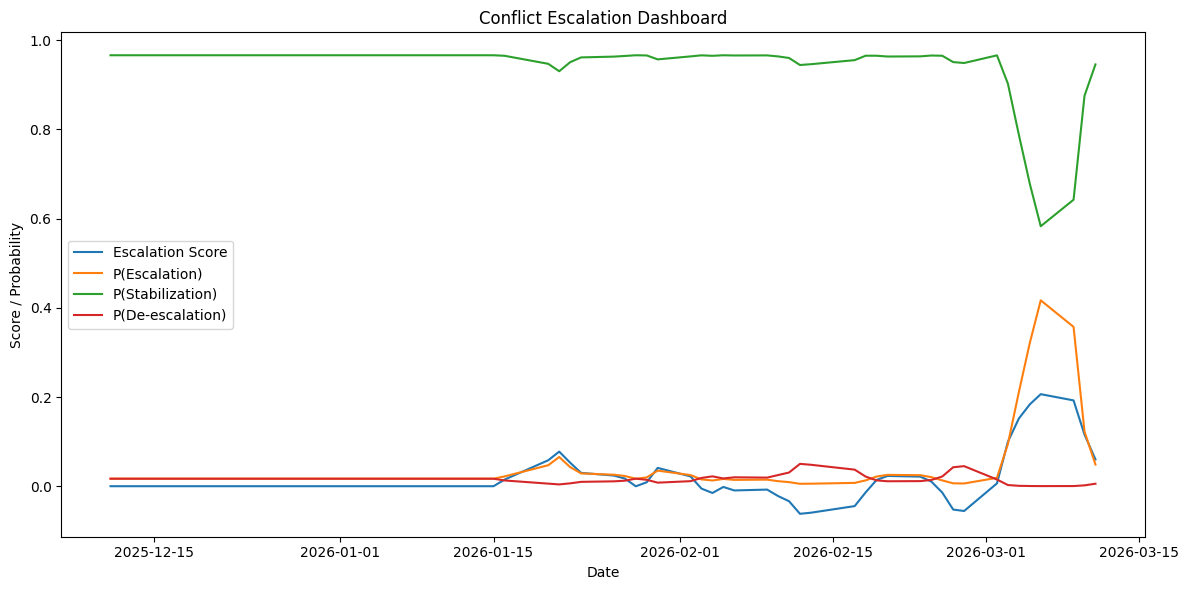

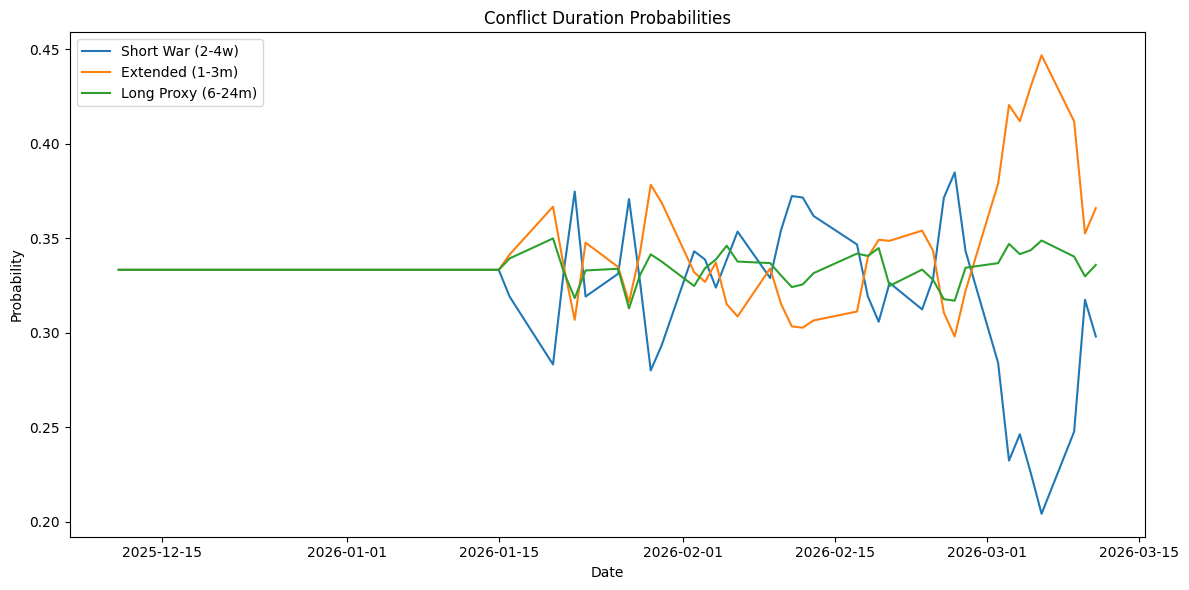

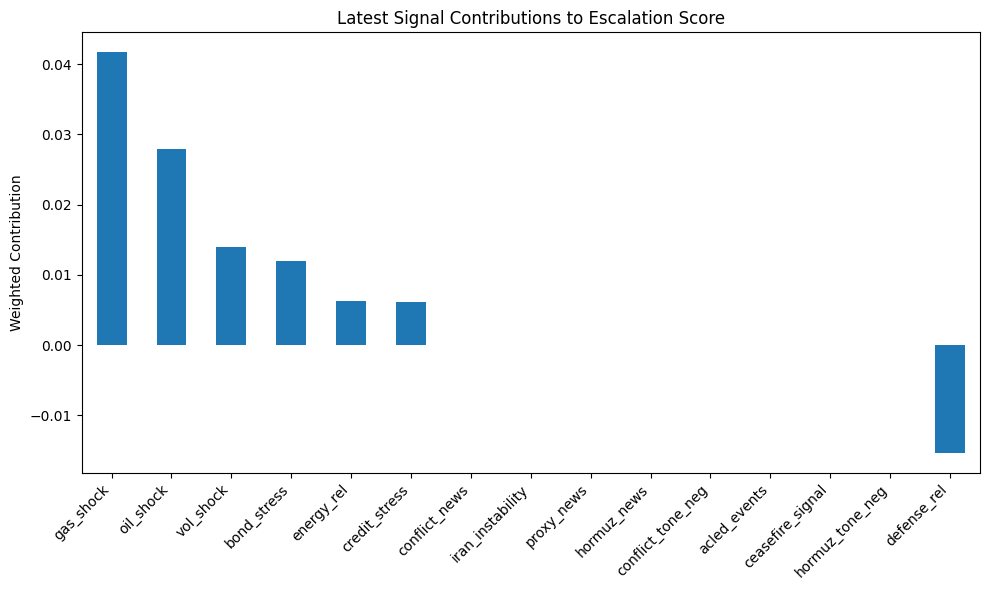

Saved:
- conflict_escalation_dashboard_output.csv
- conflict_dashboard_latest.csv
- conflict_escalation_chart.png
- conflict_duration_chart.png
- signal_contributions_chart.png


In [8]:
# SECTION 8 — Charts and CSV exports

# This section displays interactive Plotly charts for exploration,
# but saves static PNGs with matplotlib so the PDF export does not
# depend on Kaleido. This is more reliable in Colab.

# Interactive Chart 1: escalation dashboard
fig = go.Figure()
fig.add_trace(go.Scatter(x=signal.index, y=signal["escalation_score"], mode="lines", name="Escalation Score"))
fig.add_trace(go.Scatter(x=signal.index, y=signal["p_escalation"], mode="lines", name="P(Escalation)"))
fig.add_trace(go.Scatter(x=signal.index, y=signal["p_stabilization"], mode="lines", name="P(Stabilization)"))
fig.add_trace(go.Scatter(x=signal.index, y=signal["p_deescalation"], mode="lines", name="P(De-escalation)"))
fig.update_layout(
    title="Conflict Escalation Dashboard",
    xaxis_title="Date",
    yaxis_title="Score / Probability",
    template="plotly_white",
    height=600,
)
fig.show()

# Interactive Chart 2: duration probabilities
fig2 = go.Figure()
fig2.add_trace(go.Scatter(x=duration.index, y=duration["p_short_war_2_4w"], mode="lines", name="Short War (2-4w)"))
fig2.add_trace(go.Scatter(x=duration.index, y=duration["p_extended_1_3m"], mode="lines", name="Extended (1-3m)"))
fig2.add_trace(go.Scatter(x=duration.index, y=duration["p_long_proxy_6_24m"], mode="lines", name="Long Proxy (6-24m)"))
fig2.update_layout(
    title="Conflict Duration Probabilities",
    xaxis_title="Date",
    yaxis_title="Probability",
    template="plotly_white",
    height=600,
)
fig2.show()

# Static PNG exports for PDF (matplotlib version, no kaleido needed)
plt.figure(figsize=(12, 6))
plt.plot(signal.index, signal["escalation_score"], label="Escalation Score")
plt.plot(signal.index, signal["p_escalation"], label="P(Escalation)")
plt.plot(signal.index, signal["p_stabilization"], label="P(Stabilization)")
plt.plot(signal.index, signal["p_deescalation"], label="P(De-escalation)")
plt.title("Conflict Escalation Dashboard")
plt.xlabel("Date")
plt.ylabel("Score / Probability")
plt.legend()
plt.tight_layout()
plt.savefig(OUTPUT_IMG_ESC, dpi=220, bbox_inches="tight")
plt.show()
plt.close()

plt.figure(figsize=(12, 6))
plt.plot(duration.index, duration["p_short_war_2_4w"], label="Short War (2-4w)")
plt.plot(duration.index, duration["p_extended_1_3m"], label="Extended (1-3m)")
plt.plot(duration.index, duration["p_long_proxy_6_24m"], label="Long Proxy (6-24m)")
plt.title("Conflict Duration Probabilities")
plt.xlabel("Date")
plt.ylabel("Probability")
plt.legend()
plt.tight_layout()
plt.savefig(OUTPUT_IMG_DUR, dpi=220, bbox_inches="tight")
plt.show()
plt.close()

# Signal contribution chart
plt.figure(figsize=(10, 6))
contrib.plot(kind="bar")
plt.title("Latest Signal Contributions to Escalation Score")
plt.ylabel("Weighted Contribution")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.savefig(OUTPUT_IMG_CONTRIB, dpi=220, bbox_inches="tight")
plt.show()
plt.close()

# CSV exports
out = signal.join(duration, how="left")
out.to_csv(OUTPUT_CSV_FULL)
dashboard.to_csv(OUTPUT_CSV_LATEST)

print("Saved:")
print(f"- {OUTPUT_CSV_FULL}")
print(f"- {OUTPUT_CSV_LATEST}")
print(f"- {OUTPUT_IMG_ESC}")
print(f"- {OUTPUT_IMG_DUR}")
print(f"- {OUTPUT_IMG_CONTRIB}")



## Section 9 — PDF report generator

In [9]:

# SECTION 9 — PDF report generator

from reportlab.lib.pagesizes import letter
from reportlab.lib import colors
from reportlab.lib.units import inch
from reportlab.lib.styles import getSampleStyleSheet, ParagraphStyle
from reportlab.platypus import (
    SimpleDocTemplate, Paragraph, Spacer, Table, TableStyle,
    Image, PageBreak
)
from reportlab.lib.enums import TA_LEFT, TA_CENTER

doc = SimpleDocTemplate(
    OUTPUT_PDF,
    pagesize=letter,
    rightMargin=0.6 * inch,
    leftMargin=0.6 * inch,
    topMargin=0.65 * inch,
    bottomMargin=0.65 * inch
)

styles = getSampleStyleSheet()

title_style = ParagraphStyle(
    "TitleStyle",
    parent=styles["Title"],
    fontName="Helvetica-Bold",
    fontSize=20,
    leading=24,
    textColor=colors.HexColor("#163A5F"),
    alignment=TA_CENTER,
    spaceAfter=10
)

subtitle_style = ParagraphStyle(
    "SubtitleStyle",
    parent=styles["Normal"],
    fontName="Helvetica",
    fontSize=10,
    leading=13,
    textColor=colors.HexColor("#4F5D75"),
    alignment=TA_CENTER,
    spaceAfter=18
)

section_style = ParagraphStyle(
    "SectionStyle",
    parent=styles["Heading2"],
    fontName="Helvetica-Bold",
    fontSize=12,
    leading=15,
    textColor=colors.HexColor("#163A5F"),
    spaceBefore=10,
    spaceAfter=8
)

body_style = ParagraphStyle(
    "BodyStyle",
    parent=styles["BodyText"],
    fontName="Helvetica",
    fontSize=9.5,
    leading=13,
    textColor=colors.black,
    alignment=TA_LEFT,
    spaceAfter=7
)

small_style = ParagraphStyle(
    "SmallStyle",
    parent=styles["BodyText"],
    fontName="Helvetica",
    fontSize=8,
    leading=11,
    textColor=colors.HexColor("#555555"),
    alignment=TA_LEFT,
    spaceAfter=6
)

story = []

story.append(Paragraph("Conflict Escalation Dashboard Report", title_style))
story.append(Paragraph(
    f"Automated portfolio risk monitor | Generated {pd.Timestamp.utcnow().strftime('%Y-%m-%d %H:%M UTC')}",
    subtitle_style
))

summary_text = (
    "This report summarizes the model's current read on conflict escalation risk, "
    "probabilistic conflict duration, and the associated portfolio regime. "
    "The framework combines market-derived signals, optional event data, and available news proxies."
)
story.append(Paragraph(summary_text, body_style))
story.append(Spacer(1, 0.12 * inch))

table_value_style = ParagraphStyle(
    "TableValueStyle",
    parent=styles["BodyText"],
    fontName="Helvetica",
    fontSize=9,
    leading=11,
    textColor=colors.black,
    alignment=TA_LEFT,
    wordWrap="CJK",
)

table_label_style = ParagraphStyle(
    "TableLabelStyle",
    parent=styles["BodyText"],
    fontName="Helvetica",
    fontSize=9,
    leading=11,
    textColor=colors.black,
    alignment=TA_LEFT,
)

summary_rows = [
    [Paragraph("Metric", small_style), Paragraph("Latest", small_style)],
    [Paragraph("Escalation Score", table_label_style), Paragraph(fmt_num(signal.loc[latest_idx, "escalation_score"]), table_value_style)],
    [Paragraph("P(De-escalation)", table_label_style), Paragraph(fmt_pct(signal.loc[latest_idx, "p_deescalation"]), table_value_style)],
    [Paragraph("P(Stabilization)", table_label_style), Paragraph(fmt_pct(signal.loc[latest_idx, "p_stabilization"]), table_value_style)],
    [Paragraph("P(Escalation)", table_label_style), Paragraph(fmt_pct(signal.loc[latest_idx, "p_escalation"]), table_value_style)],
    [Paragraph("P(Short War 2-4w)", table_label_style), Paragraph(fmt_pct(duration.loc[latest_idx, "p_short_war_2_4w"]), table_value_style)],
    [Paragraph("P(Extended 1-3m)", table_label_style), Paragraph(fmt_pct(duration.loc[latest_idx, "p_extended_1_3m"]), table_value_style)],
    [Paragraph("P(Long Proxy 6-24m)", table_label_style), Paragraph(fmt_pct(duration.loc[latest_idx, "p_long_proxy_6_24m"]), table_value_style)],
    [Paragraph("Portfolio Regime", table_label_style), Paragraph(str(signal.loc[latest_idx, "portfolio_regime"]), table_value_style)],
    [Paragraph("Recommended Action", table_label_style), Paragraph(str(signal.loc[latest_idx, "recommended_actions"]), table_value_style)],
]

summary_table = Table(summary_rows, colWidths=[2.0 * inch, 5.0 * inch], repeatRows=1)
summary_table.setStyle(TableStyle([
    ("BACKGROUND", (0, 0), (-1, 0), colors.HexColor("#163A5F")),
    ("TEXTCOLOR", (0, 0), (-1, 0), colors.white),
    ("FONTNAME", (0, 0), (-1, 0), "Helvetica-Bold"),
    ("ROWBACKGROUNDS", (0, 1), (-1, -1), [colors.whitesmoke, colors.HexColor("#EEF3F8")]),
    ("GRID", (0, 0), (-1, -1), 0.4, colors.HexColor("#AAB7C4")),
    ("VALIGN", (0, 0), (-1, -1), "TOP"),
    ("LEFTPADDING", (0, 0), (-1, -1), 8),
    ("RIGHTPADDING", (0, 0), (-1, -1), 8),
    ("TOPPADDING", (0, 0), (-1, -1), 6),
    ("BOTTOMPADDING", (0, 0), (-1, -1), 6),
]))
story.append(summary_table)
story.append(Spacer(1, 0.18 * inch))

story.append(Paragraph("Interpretation", section_style))
interpretation_text = (
    f"The model currently indicates a <b>{signal.loc[latest_idx, 'portfolio_regime']}</b> regime. "
    f"Near-term conflict duration probabilities are tilted toward "
    f"<b>{fmt_pct(duration.loc[latest_idx, 'p_extended_1_3m'])}</b> for an extended 1-3 month conflict, "
    f"versus <b>{fmt_pct(duration.loc[latest_idx, 'p_short_war_2_4w'])}</b> for a short war and "
    f"<b>{fmt_pct(duration.loc[latest_idx, 'p_long_proxy_6_24m'])}</b> for a long proxy conflict."
)
story.append(Paragraph(interpretation_text, body_style))

story.append(Paragraph("Method / caveat notes", section_style))
story.append(Paragraph(
    "This version is partially dependent on available market data and may be constrained by news API rate limits. "
    "If GDELT or ACLED do not fully populate, the model leans more heavily on market-derived signals.",
    small_style
))

story.append(PageBreak())

story.append(Paragraph("Conflict Escalation Trend", section_style))
story.append(Image(OUTPUT_IMG_ESC, width=7.1 * inch, height=4.0 * inch))
story.append(Spacer(1, 0.18 * inch))
story.append(Paragraph("Conflict Duration Probabilities", section_style))
story.append(Image(OUTPUT_IMG_DUR, width=7.1 * inch, height=4.0 * inch))

story.append(PageBreak())

story.append(Paragraph("Signal Contributions", section_style))
story.append(Image(OUTPUT_IMG_CONTRIB, width=6.9 * inch, height=4.3 * inch))
story.append(Spacer(1, 0.15 * inch))

story.append(Paragraph("Latest Probability Snapshot", section_style))
detail_rows = [
    ["Category", "Value"],
    ["Escalation Score", fmt_num(signal.loc[latest_idx, "escalation_score"])],
    ["Escalation Probability", fmt_pct(signal.loc[latest_idx, "p_escalation"])],
    ["Stabilization Probability", fmt_pct(signal.loc[latest_idx, "p_stabilization"])],
    ["De-escalation Probability", fmt_pct(signal.loc[latest_idx, "p_deescalation"])],
    ["Short War (2-4 weeks)", fmt_pct(duration.loc[latest_idx, "p_short_war_2_4w"])],
    ["Extended Conflict (1-3 months)", fmt_pct(duration.loc[latest_idx, "p_extended_1_3m"])],
    ["Long Proxy Conflict (6-24 months)", fmt_pct(duration.loc[latest_idx, "p_long_proxy_6_24m"])],
]
detail_table = Table(detail_rows, colWidths=[3.5 * inch, 2.7 * inch])
detail_table.setStyle(TableStyle([
    ("BACKGROUND", (0, 0), (-1, 0), colors.HexColor("#163A5F")),
    ("TEXTCOLOR", (0, 0), (-1, 0), colors.white),
    ("FONTNAME", (0, 0), (-1, 0), "Helvetica-Bold"),
    ("ROWBACKGROUNDS", (0, 1), (-1, -1), [colors.whitesmoke, colors.HexColor("#EEF3F8")]),
    ("GRID", (0, 0), (-1, -1), 0.4, colors.HexColor("#AAB7C4")),
    ("VALIGN", (0, 0), (-1, -1), "MIDDLE"),
    ("LEFTPADDING", (0, 0), (-1, -1), 8),
    ("RIGHTPADDING", (0, 0), (-1, -1), 8),
    ("TOPPADDING", (0, 0), (-1, -1), 6),
    ("BOTTOMPADDING", (0, 0), (-1, -1), 6),
]))
story.append(detail_table)

doc.build(story)
print(f"Saved PDF report: {OUTPUT_PDF}")

Saved PDF report: conflict_dashboard_report.pdf


## Section 10 — Final output links

In Colab / Jupyter, these paths will be clickable from the file browser after the cells run.

In [10]:

# SECTION 10 — Final output summary

print("Artifacts ready:")
print(f"- Notebook outputs CSV: {OUTPUT_CSV_FULL}")
print(f"- Latest dashboard CSV: {OUTPUT_CSV_LATEST}")
print(f"- PDF report: {OUTPUT_PDF}")

Artifacts ready:
- Notebook outputs CSV: conflict_escalation_dashboard_output.csv
- Latest dashboard CSV: conflict_dashboard_latest.csv
- PDF report: conflict_dashboard_report.pdf
